In [1]:
# Slide 9
# Image Data
# https://www.imageprocessingplace.com/DIP-3E/dip3e_book_images_downloads.htm

import cv2
import numpy as np
import matplotlib.pyplot as plt

9.1.1 – Edge Detection using Sobel Gradient masks

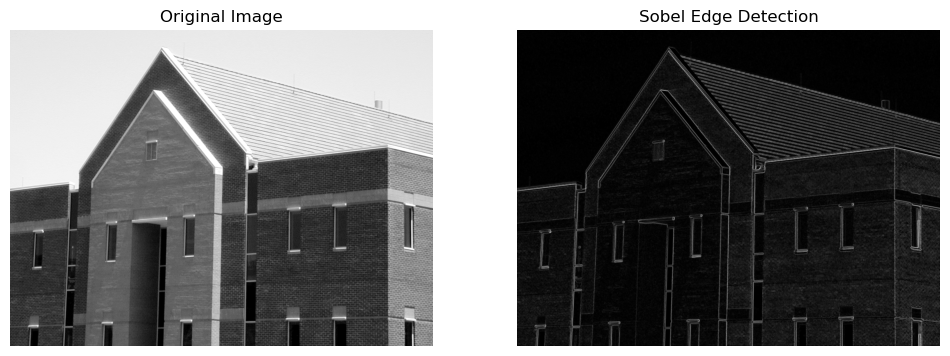

In [2]:
# Load the image
image_path = 'DIP3E_Original_Images_CH10/Fig1016(a)(building_original).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Sobel kernels
sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
sobel_y = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]])

# Manual convolution using filter2D as a primitive
grad_x = cv2.filter2D(img.astype(float), -1, sobel_x)
grad_y = cv2.filter2D(img.astype(float), -1, sobel_y)

# Gradient magnitude
sobel_combined = np.sqrt(grad_x**2 + grad_y**2)
sobel_combined = (sobel_combined / sobel_combined.max() * 255).astype(np.uint8)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1); plt.imshow(img, cmap='gray'); plt.title('Original Image'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(sobel_combined, cmap='gray'); plt.title('Sobel Edge Detection'); plt.axis('off')
plt.show()

9.1.2 – Edge Detection using Prewitt Gradient masks

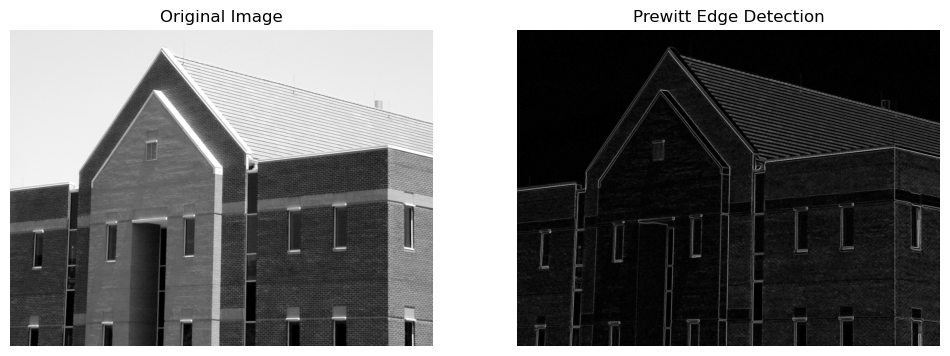

In [3]:
# Load the image
image_path = 'DIP3E_Original_Images_CH10/Fig1016(a)(building_original).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Prewitt kernels
prewitt_x = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]])
prewitt_y = np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]])

grad_x = cv2.filter2D(img.astype(float), -1, prewitt_x)
grad_y = cv2.filter2D(img.astype(float), -1, prewitt_y)

prewitt_combined = np.sqrt(grad_x**2 + grad_y**2)
prewitt_combined = (prewitt_combined / prewitt_combined.max() * 255).astype(np.uint8)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1); plt.imshow(img, cmap='gray'); plt.title('Original Image'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(prewitt_combined, cmap='gray'); plt.title('Prewitt Edge Detection'); plt.axis('off')
plt.show()

9.2 – Image Smoothing with Gaussian filter followed by Sobel Edge Detection

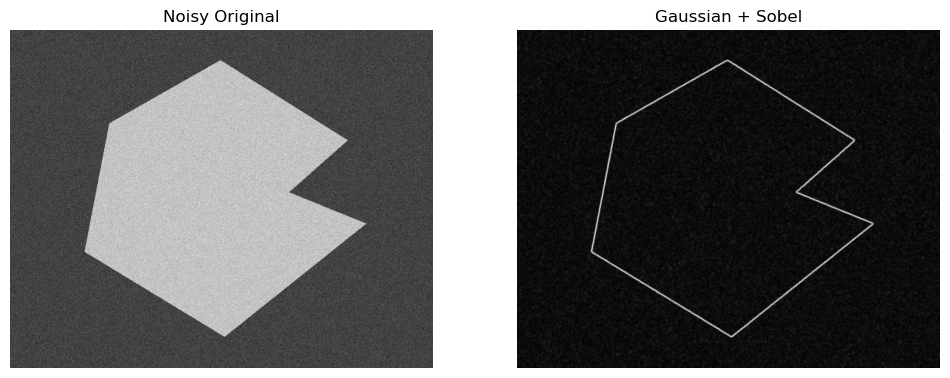

In [4]:
# Load the image
image_path = 'DIP3E_Original_Images_CH10/Fig1036(b)(gaussian_noise_mean_0_std_10_added).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Gaussian kernel for smoothing
gaussian_blur = cv2.GaussianBlur(img, (5, 5), 1.0)

# Sobel on smoothed image
sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
sobel_y = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]])

gx = cv2.filter2D(gaussian_blur.astype(float), -1, sobel_x)
gy = cv2.filter2D(gaussian_blur.astype(float), -1, sobel_y)
smooth_edge = np.sqrt(gx**2 + gy**2)
smooth_edge = (smooth_edge / smooth_edge.max() * 255).astype(np.uint8)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1); plt.imshow(img, cmap='gray'); plt.title('Noisy Original'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(smooth_edge, cmap='gray'); plt.title('Gaussian + Sobel'); plt.axis('off')
plt.show()

9.3 – Laplacian of Gaussian (LoG) Edge Detection for zero-crossings

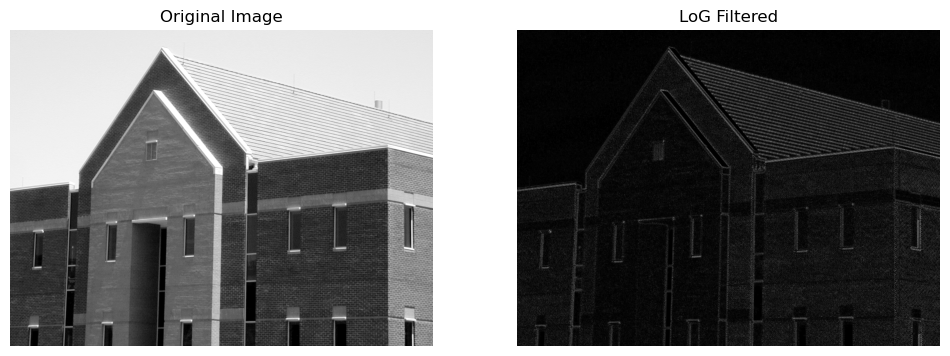

In [5]:
# Load the image
image_path = 'DIP3E_Original_Images_CH10/Fig1016(a)(building_original).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# LoG operator (approximate 5x5 LoG kernel)
log_kernel = np.array([[0, 0, -1, 0, 0],
                       [0, -1, -2, -1, 0],
                       [-1, -2, 16, -2, -1],
                       [0, -1, -2, -1, 0],
                       [0, 0, -1, 0, 0]])

log_filtered = cv2.filter2D(img.astype(float), -1, log_kernel)

# Scaling for display
log_display = np.abs(log_filtered)
log_display = (log_display / log_display.max() * 255).astype(np.uint8)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1); plt.imshow(img, cmap='gray'); plt.title('Original Image'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(log_display, cmap='gray'); plt.title('LoG Filtered'); plt.axis('off')
plt.show()

9.4 – Hough Transform implementation from scratch for Line Detection

[ WARN:0@2.712] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34016 (0x84e0) encountered
[ WARN:0@2.712] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34017 (0x84e1) encountered
[ WARN:0@2.712] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34018 (0x84e2) encountered
[ WARN:0@2.712] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34019 (0x84e3) encountered
[ WARN:0@2.712] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34020 (0x84e4) encountered
[ WARN:0@2.712] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34021 (0x84e5) encountered
[ WARN:0@2.712] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34022 (0x84e6) encountered
[ WARN:0@2.712] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34023 (0x84e7) encountered
[ WARN:0

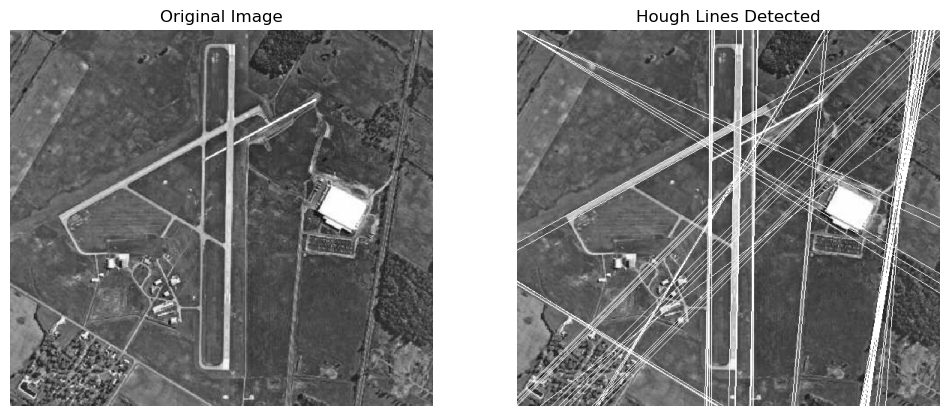

In [6]:
# Load the image
image_path = 'DIP3E_Original_Images_CH10/Fig1034(a)(marion_airport).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Threshold for binary edges
edges = cv2.Canny(img, 100, 200)

# Accumulator setup
H, W = edges.shape
diag_len = int(np.sqrt(H**2 + W**2))
rhos = np.linspace(-diag_len, diag_len, diag_len * 2)
thetas = np.deg2rad(np.arange(-90.0, 90.0))
accumulator = np.zeros((len(rhos), len(thetas)), dtype=np.uint64)

# Voting process
y_idxs, x_idxs = np.nonzero(edges)
for i in range(len(x_idxs)):
    x, y = x_idxs[i], y_idxs[i]
    for t_idx in range(len(thetas)):
        rho = int(x * np.cos(thetas[t_idx]) + y * np.sin(thetas[t_idx])) + diag_len
        accumulator[rho, t_idx] += 1

# Finding peaks and drawing
hough_img = img.copy()
line_indices = np.argwhere(accumulator > 150) # Thresholding peaks
for r_idx, t_idx in line_indices:
    rho = rhos[r_idx]
    theta = thetas[t_idx]
    a, b = np.cos(theta), np.sin(theta)
    x0, y0 = a * rho, b * rho
    pt1 = (int(x0 + 1000 * (-b)), int(y0 + 1000 * (a)))
    pt2 = (int(x0 - 1000 * (-b)), int(y0 - 1000 * (a)))
    cv2.line(hough_img, pt1, pt2, (255), 1)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1); plt.imshow(img, cmap='gray'); plt.title('Original Image'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(hough_img, cmap='gray'); plt.title('Hough Lines Detected'); plt.axis('off')
plt.show()

9.5 – Line Detection using Directional Masks (Horizontal and Vertical)

[ WARN:0@22.439] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34016 (0x84e0) encountered
[ WARN:0@22.439] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34017 (0x84e1) encountered
[ WARN:0@22.439] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34018 (0x84e2) encountered
[ WARN:0@22.439] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34019 (0x84e3) encountered
[ WARN:0@22.439] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34020 (0x84e4) encountered
[ WARN:0@22.439] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34021 (0x84e5) encountered
[ WARN:0@22.439] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34022 (0x84e6) encountered
[ WARN:0@22.439] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34023 (0x84e7) encountered


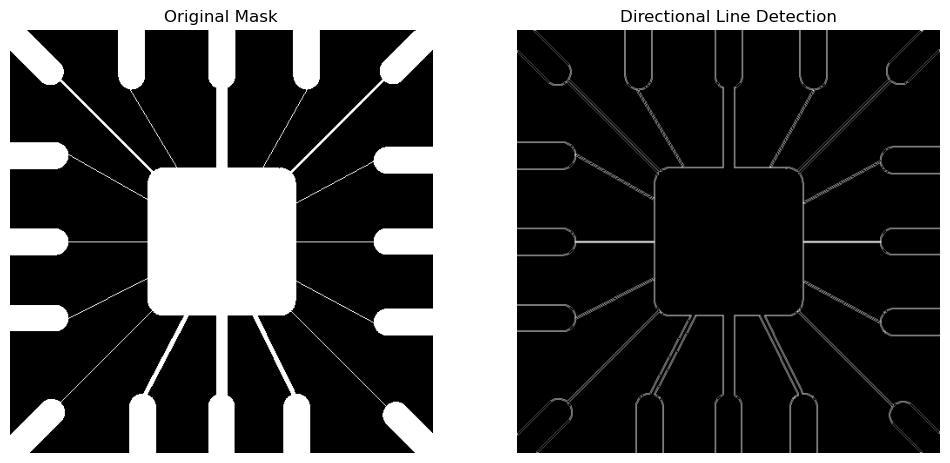

In [7]:
# Load the image
image_path = 'DIP3E_Original_Images_CH10/Fig1005(a)(wirebond_mask).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Directional masks
horizontal_mask = np.array([[-1, -1, -1], [2, 2, 2], [-1, -1, -1]])
vertical_mask = np.array([[-1, 2, -1], [-1, 2, -1], [-1, 2, -1]])

h_lines = cv2.filter2D(img.astype(float), -1, horizontal_mask)
v_lines = cv2.filter2D(img.astype(float), -1, vertical_mask)

# Combine for visualization
directional_combined = np.abs(h_lines) + np.abs(v_lines)
directional_combined = (directional_combined / directional_combined.max() * 255).astype(np.uint8)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1); plt.imshow(img, cmap='gray'); plt.title('Original Mask'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(directional_combined, cmap='gray'); plt.title('Directional Line Detection'); plt.axis('off')
plt.show()

9.6 – Effect of high-level Noise on Edge Detection performance

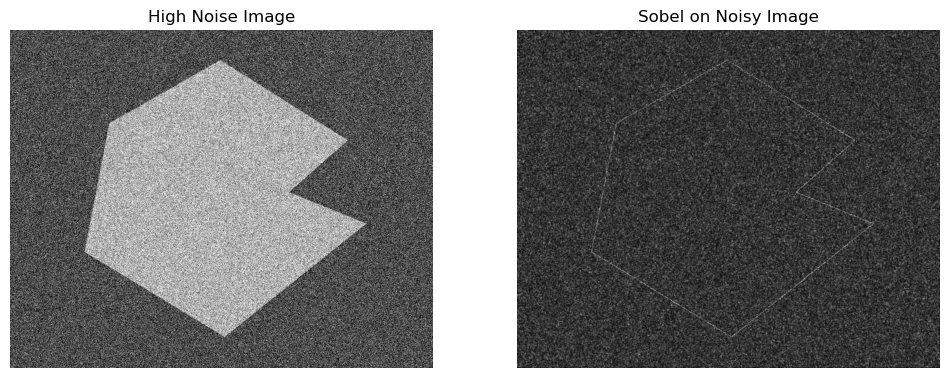

In [8]:
# Load the image
image_path = 'DIP3E_Original_Images_CH10/Fig1036(c)(gaussian_noise_mean_0_std_50_added).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Sobel on high noise image
sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
sobel_y = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]])

gx = cv2.filter2D(img.astype(float), -1, sobel_x)
gy = cv2.filter2D(img.astype(float), -1, sobel_y)
noisy_edge = np.sqrt(gx**2 + gy**2)
noisy_edge = (noisy_edge / noisy_edge.max() * 255).astype(np.uint8)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1); plt.imshow(img, cmap='gray'); plt.title('High Noise Image'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(noisy_edge, cmap='gray'); plt.title('Sobel on Noisy Image'); plt.axis('off')
plt.show()

9.7 – Detection of Discontinuities (Point detection) using Laplacian mask

[ WARN:0@22.738] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34016 (0x84e0) encountered
[ WARN:0@22.738] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34017 (0x84e1) encountered
[ WARN:0@22.738] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34018 (0x84e2) encountered
[ WARN:0@22.738] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34019 (0x84e3) encountered
[ WARN:0@22.738] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34020 (0x84e4) encountered
[ WARN:0@22.738] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34021 (0x84e5) encountered
[ WARN:0@22.738] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34022 (0x84e6) encountered
[ WARN:0@22.738] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34023 (0x84e7) encountered


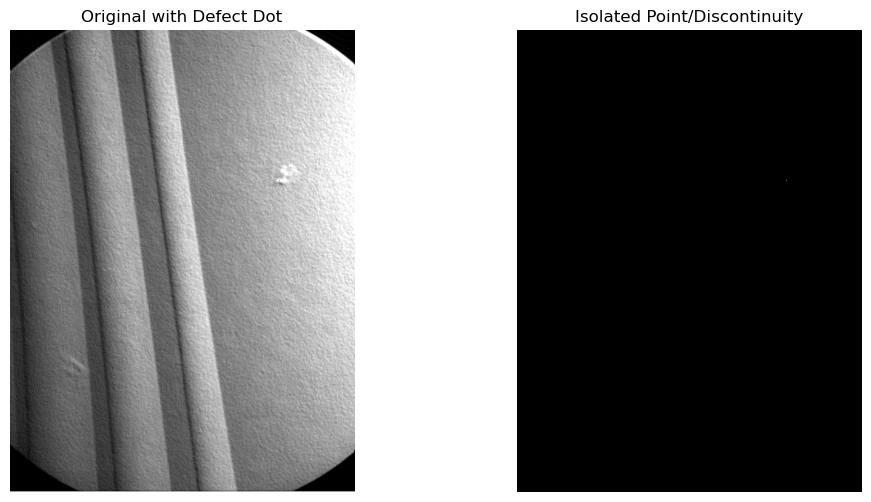

In [9]:
# Load the image
image_path = 'DIP3E_Original_Images_CH10/Fig1004(b)(turbine_blade_black_dot).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Point detection mask (Laplacian-like)
point_mask = np.array([[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]])

points = cv2.filter2D(img.astype(float), -1, point_mask)
points = np.abs(points)

# Thresholding to isolate the point
threshold = points.max() * 0.9
point_isolated = (points > threshold).astype(np.uint8) * 255

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1); plt.imshow(img, cmap='gray'); plt.title('Original with Defect Dot'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(point_isolated, cmap='gray'); plt.title('Isolated Point/Discontinuity'); plt.axis('off')
plt.show()

9.8 – Effect of noise on 1st vs 2nd Derivative filters

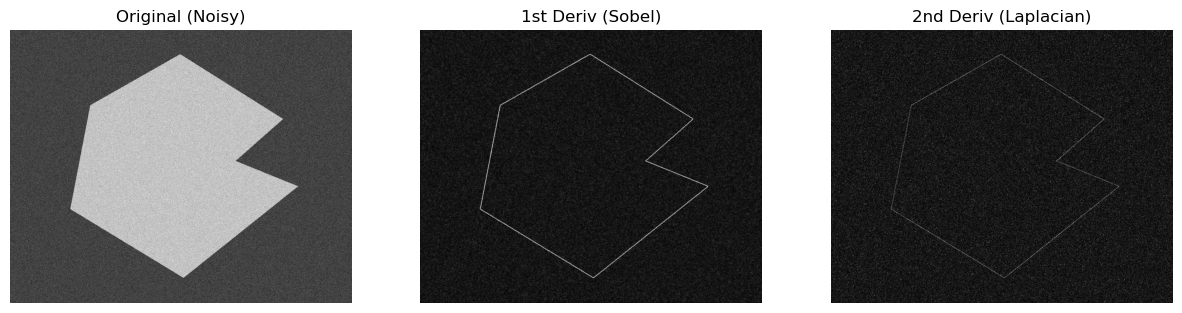

In [10]:
# Load the image
image_path = 'DIP3E_Original_Images_CH10/Fig1036(b)(gaussian_noise_mean_0_std_10_added).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Sobel 1st Deriv
sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
sobel_y = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]])
gx = cv2.filter2D(img.astype(float), -1, sobel_x)
gy = cv2.filter2D(img.astype(float), -1, sobel_y)
mag = np.sqrt(gx**2 + gy**2)

# Laplacian 2nd Deriv
lap_mask = np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]])
lap = np.abs(cv2.filter2D(img.astype(float), -1, lap_mask))

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1); plt.imshow(img, cmap='gray'); plt.title('Original (Noisy)'); plt.axis('off')
plt.subplot(1, 3, 2); plt.imshow(mag, cmap='gray'); plt.title('1st Deriv (Sobel)'); plt.axis('off')
plt.subplot(1, 3, 3); plt.imshow(lap, cmap='gray'); plt.title('2nd Deriv (Laplacian)'); plt.axis('off')
plt.show()

9.9 – Edge Linking using Local Processing (Gradient Magnitude/Direction)

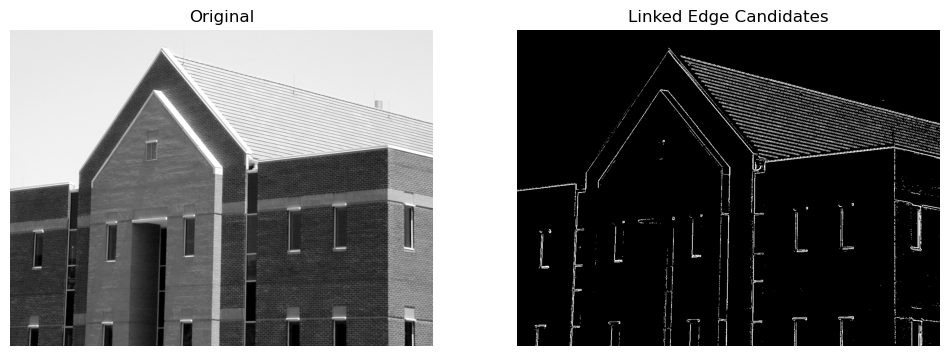

In [11]:
# Load the image
image_path = 'DIP3E_Original_Images_CH10/Fig1016(a)(building_original).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Calculate magnitude and direction
gx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
gy = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
mag = np.sqrt(gx**2 + gy**2)
angle = np.arctan2(gy, gx)

# Link pixels by thresholding magnitude (basic local linking candidate selection)
linked = (mag > (mag.max() * 0.3)).astype(np.uint8) * 255

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1); plt.imshow(img, cmap='gray'); plt.title('Original'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(linked, cmap='gray'); plt.title('Linked Edge Candidates'); plt.axis('off')
plt.show()

9.10 – Global Processing: Hough Transform for Line Detection

[ WARN:0@23.251] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34016 (0x84e0) encountered
[ WARN:0@23.251] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34017 (0x84e1) encountered
[ WARN:0@23.251] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34018 (0x84e2) encountered
[ WARN:0@23.251] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34019 (0x84e3) encountered
[ WARN:0@23.251] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34020 (0x84e4) encountered
[ WARN:0@23.251] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34021 (0x84e5) encountered
[ WARN:0@23.251] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34022 (0x84e6) encountered
[ WARN:0@23.251] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34023 (0x84e7) encountered


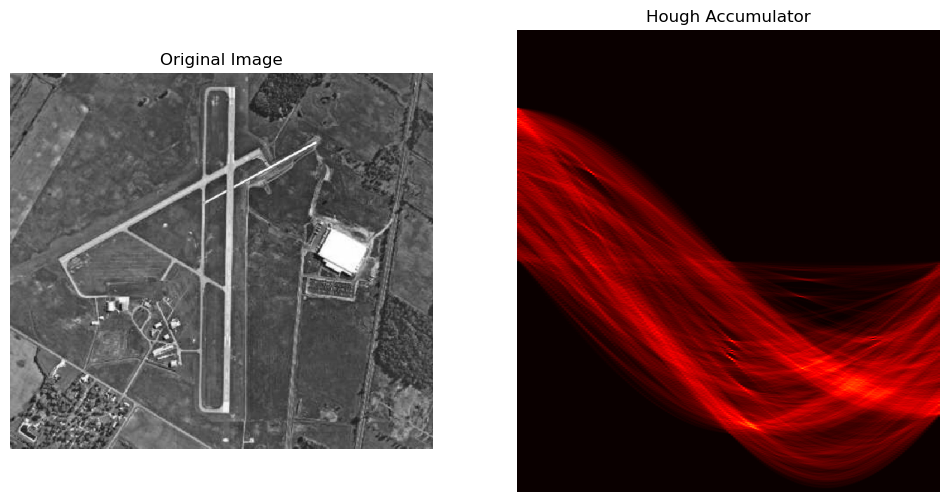

In [12]:
# Load the image
image_path = 'DIP3E_Original_Images_CH10/Fig1034(a)(marion_airport).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
edges = cv2.Canny(img, 100, 200)

# Discretize parameter space
thetas = np.deg2rad(np.arange(-90.0, 90.0))
diag_len = int(np.sqrt(img.shape[0]**2 + img.shape[1]**2))
accumulator = np.zeros((2 * diag_len, len(thetas)), dtype=np.uint64)

# Voting
y_idxs, x_idxs = np.nonzero(edges)
for i in range(len(x_idxs)):
    x, y = x_idxs[i], y_idxs[i]
    for t_idx in range(len(thetas)):
        rho = int(round(x * np.cos(thetas[t_idx]) + y * np.sin(thetas[t_idx]))) + diag_len
        accumulator[rho, t_idx] += 1

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1); plt.imshow(img, cmap='gray'); plt.title('Original Image'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(accumulator, cmap='hot', aspect='auto'); plt.title('Hough Accumulator'); plt.axis('off')
plt.show()